# IEEE-CIS EDA and Pseudo-Entity Selection

Notebook này là báo cáo EDA chính cho `train_transaction.csv`. Raw CSV được query trực tiếp bằng DuckDB để giới hạn RAM; pandas chỉ nhận các bảng tổng hợp và mẫu cần cho visualization. Phần cuối tính lại pseudo-entity metrics từ raw data và trình bày quyết định research trong notebook.

In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src' / 'pit_feature_store').exists():
    project_root = project_root.parent

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pit_feature_store.entity_selection import (
    export_entity_candidate_results,
    generate_entity_candidate_results,
)

data_path = project_root / 'data' / 'raw' / 'ieee' / 'train_transaction.csv'
output_report_path = project_root / 'artifacts' / 'reports' / 'entity_candidate_results.csv'
important_columns = [
    'TransactionID', 'TransactionDT', 'TransactionAmt', 'isFraud',
    'card1', 'card2', 'card5', 'addr1', 'D1',
]

if not data_path.exists():
    raise FileNotFoundError(f'Không tìm thấy raw dataset: {data_path}')

connection = duckdb.connect()
escaped_data_path = data_path.as_posix().replace("'", "''")
connection.execute(
    f"""
    CREATE OR REPLACE TEMP VIEW raw_transactions AS
    SELECT *
    FROM read_csv_auto('{escaped_data_path}', header = true)
    """
)
plt.style.use('seaborn-v0_8-whitegrid')
data_path

WindowsPath('c:/Users/tiennd49/Documents/point-in-time-feature-store/data/raw/ieee/train_transaction.csv')

## 1. Dataset Overview

Kiểm tra kích thước, schema đầy đủ, vài dòng đầu, khoảng thời gian tương đối và fraud rate tổng thể.

In [2]:
schema = connection.sql('DESCRIBE raw_transactions').df()
overview = connection.sql(
    """
    SELECT
        COUNT(*) AS row_count,
        MIN(TransactionDT) AS min_transaction_dt,
        MAX(TransactionDT) AS max_transaction_dt,
        SUM(CASE WHEN isFraud = 1 THEN 1 ELSE 0 END) AS fraud_count,
        ROUND(100.0 * AVG(isFraud), 4) AS fraud_pct
    FROM raw_transactions
    """
).df()
overview.insert(1, 'column_count', len(schema))
head = connection.sql(
    f"SELECT {', '.join(important_columns)} FROM raw_transactions LIMIT 5"
).df()

display(overview)
display(schema[['column_name', 'column_type', 'null']])
display(head)

,row_count,column_count,min_transaction_dt,max_transaction_dt,fraud_count,fraud_pct
0,590540,394,86400,15811131,20663.0,3.499


,column_name,column_type,null
0,TransactionID,BIGINT,YES
1,isFraud,BIGINT,YES
2,TransactionDT,BIGINT,YES
3,TransactionAmt,DOUBLE,YES
4,ProductCD,VARCHAR,YES
...,...,...,...
389,V335,DOUBLE,YES
390,V336,DOUBLE,YES
391,V337,DOUBLE,YES
392,V338,DOUBLE,YES


,TransactionID,TransactionDT,TransactionAmt,isFraud,card1,card2,card5,addr1,D1
0,2987000,86400,68.5,0,13926,NaN,142.0,315.0,14.0
1,2987001,86401,29.0,0,2755,404.0,102.0,325.0,0.0
2,2987002,86469,59.0,0,4663,490.0,166.0,330.0,0.0
3,2987003,86499,50.0,0,18132,567.0,117.0,476.0,112.0
4,2987004,86506,50.0,0,4497,514.0,102.0,420.0,0.0


IEEE-CIS có nhiều cột hơn phạm vi feature store hiện tại. Phân tích sâu bên dưới tập trung vào các cột trực tiếp tham gia label, event time, amount và pseudo-entity; toàn bộ tên cột/dtype vẫn được hiển thị để reviewer nhìn thấy schema đầu vào.

## 2. Schema and Basic Statistics

Các percentile cao giúp nhìn rõ tail của amount và các biến nhận dạng tốt hơn chỉ dùng `describe()` mặc định.

In [3]:
statistics_sql = ' UNION ALL '.join(
    f"""
    SELECT
        '{column}' AS column,
        COUNT({column}) AS count,
        AVG({column}) AS mean,
        MEDIAN({column}) AS median,
        STDDEV_SAMP({column}) AS std,
        MIN({column}) AS min,
        QUANTILE_CONT({column}, 0.25) AS p25,
        QUANTILE_CONT({column}, 0.75) AS p75,
        QUANTILE_CONT({column}, 0.95) AS p95,
        QUANTILE_CONT({column}, 0.99) AS p99,
        MAX({column}) AS max
    FROM raw_transactions
    """
    for column in important_columns
)
basic_statistics = connection.sql(statistics_sql).df()
display(basic_statistics)

,column,count,mean,median,std,min,p25,p75,p95,p99,max
0,TransactionID,590540,3.282270e+06,3282269.500,1.704744e+05,2987000.000,3134634.750,3429904.25,3548012.05,3571633.61,3.577539e+06
1,TransactionDT,590540,7.372311e+06,7306527.500,4.617224e+06,86400.000,3027057.750,11246620.00,14857872.15,15629766.04,1.581113e+07
2,TransactionAmt,590540,1.350272e+02,68.769,2.391625e+02,0.251,43.321,125.00,445.00,1104.00,3.193739e+04
3,isFraud,590540,3.499001e-02,0.000,1.837546e-01,0.000,0.000,0.00,0.00,1.00,1.000000e+00
4,card1,590540,9.898735e+03,9678.000,4.901170e+03,1000.000,6019.000,14184.00,17319.00,18238.00,1.839600e+04
5,card2,581607,3.625555e+02,361.000,1.577932e+02,100.000,214.000,512.00,567.00,583.00,6.000000e+02
6,card5,586281,1.992789e+02,226.000,4.124445e+01,100.000,166.000,226.00,226.00,226.00,2.370000e+02
7,addr1,524834,2.907338e+02,299.000,1.017411e+02,100.000,204.000,330.00,485.00,512.00,5.400000e+02
8,D1,589271,9.434757e+01,3.000,1.576604e+02,0.000,0.000,122.00,489.00,602.00,6.400000e+02


## 3. Missing Values

,column,missing_count,missing_pct
7,addr1,65706,11.13
5,card2,8933,1.51
6,card5,4259,0.72
8,D1,1269,0.21
0,TransactionID,0,0.00
4,card1,0,0.00
3,isFraud,0,0.00
2,TransactionAmt,0,0.00
1,TransactionDT,0,0.00


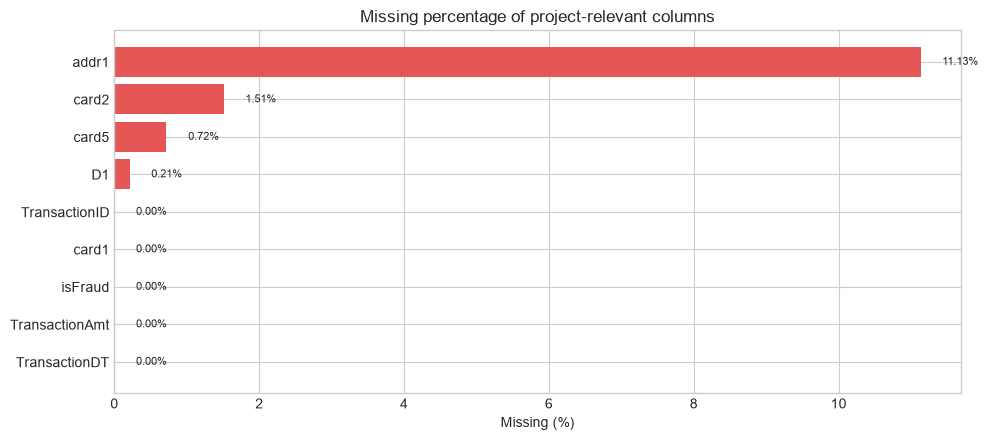

In [4]:
missing_sql = ' UNION ALL '.join(
    f"""
    SELECT
        '{column}' AS column,
        COUNT(*) FILTER (WHERE {column} IS NULL) AS missing_count,
        ROUND(
            100.0 * COUNT(*) FILTER (WHERE {column} IS NULL) / COUNT(*),
            2
        ) AS missing_pct
    FROM raw_transactions
    """
    for column in important_columns
)
missing_values = connection.sql(missing_sql).df().sort_values(
    'missing_pct', ascending=False
)
display(missing_values)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(missing_values['column'], missing_values['missing_pct'], color='#E45756')
ax.invert_yaxis()
ax.set_title('Missing percentage of project-relevant columns')
ax.set_xlabel('Missing (%)')
for index, value in enumerate(missing_values['missing_pct']):
    ax.text(value + 0.3, index, f'{value:.2f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

`card1`, `card2` và `addr1` quyết định trực tiếp coverage của UID đã chọn: chỉ dòng có đủ cả ba trường mới tạo được UID. Thêm `card5` hoặc `D1` làm điều kiện complete-case chặt hơn, nên có thể giảm coverage; riêng `D1` còn có thể chia một entity thành nhiều nhóm thời gian nhỏ. Candidate metrics ở phần 8 định lượng chính xác tác động này thay vì điền missing bằng một giá trị giả và vô tình gom các dòng không liên quan.

## 4. Data Quality Checks

Đây là EDA/reporting để quan sát dữ liệu; validation production vẫn thuộc `warehouse.py`.

In [5]:
transaction_id_quality = connection.sql(
    """
    SELECT
        COUNT(*) FILTER (WHERE TransactionID IS NULL) AS null_count,
        COUNT(TransactionID) - COUNT(DISTINCT TransactionID) AS duplicate_count,
        COUNT(DISTINCT TransactionID) AS distinct_count
    FROM raw_transactions
    """
).df()

transaction_dt_quality = connection.sql(
    """
    SELECT
        COUNT(*) FILTER (WHERE TransactionDT IS NULL) AS null_count,
        COUNT(*) FILTER (WHERE TransactionDT < 0) AS negative_count,
        MIN(TransactionDT) AS min_transaction_dt,
        MAX(TransactionDT) AS max_transaction_dt,
        TIMESTAMP '2017-12-01 00:00:00'
            + CAST(MIN(TransactionDT) AS BIGINT) * INTERVAL 1 SECOND
            AS min_event_ts,
        TIMESTAMP '2017-12-01 00:00:00'
            + CAST(MAX(TransactionDT) AS BIGINT) * INTERVAL 1 SECOND
            AS max_event_ts
    FROM raw_transactions
    """
).df()

amount_quality = connection.sql(
    """
    WITH thresholds AS (
        SELECT
            QUANTILE_CONT(TransactionAmt, 0.25) AS p25,
            QUANTILE_CONT(TransactionAmt, 0.75) AS p75,
            QUANTILE_CONT(TransactionAmt, 0.95) AS p95,
            QUANTILE_CONT(TransactionAmt, 0.99) AS p99,
            MAX(TransactionAmt) AS max_amount
        FROM raw_transactions
    )
    SELECT
        COUNT(*) FILTER (WHERE TransactionAmt IS NULL) AS null_count,
        COUNT(*) FILTER (WHERE TransactionAmt <= 0) AS non_positive_count,
        thresholds.p25, thresholds.p75, thresholds.p95, thresholds.p99,
        thresholds.max_amount,
        COUNT(*) FILTER (
            WHERE TransactionAmt
                > thresholds.p75 + 1.5 * (thresholds.p75 - thresholds.p25)
        ) AS iqr_high_outlier_count
    FROM raw_transactions
    CROSS JOIN thresholds
    GROUP BY ALL
    """
).df()

fraud_quality = connection.sql(
    """
    SELECT
        COUNT(*) FILTER (WHERE isFraud IS NULL) AS null_count,
        COUNT(DISTINCT isFraud) AS distinct_count,
        LIST_SORT(LIST(DISTINCT isFraud)) AS distinct_values,
        COUNT(*) FILTER (WHERE isFraud NOT IN (0, 1)) AS invalid_value_count
    FROM raw_transactions
    """
).df()

display(pd.concat({
    'TransactionID': transaction_id_quality,
    'TransactionDT': transaction_dt_quality,
    'TransactionAmt': amount_quality,
    'isFraud': fraud_quality,
}, names=['check']))

,,null_count,duplicate_count,distinct_count,negative_count,min_transaction_dt,max_transaction_dt,min_event_ts,max_event_ts,non_positive_count,p25,p75,p95,p99,max_amount,iqr_high_outlier_count,distinct_values,invalid_value_count
check,,,,,,,,,,,,,,,,,,
TransactionID,0,0,0.0,590540.0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDT,0,0,NaN,NaN,0.0,86400.0,15811131.0,2017-12-02,2018-06-01 23:58:51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionAmt,0,0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,0.0,43.321,125.0,445.0,1104.0,31937.391,66482.0,NaN,NaN
isFraud,0,0,NaN,2.0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0, 1]",0.0


`TransactionID` cần duy nhất để làm event/label ID. `TransactionDT` phải không âm và được chuẩn hóa bằng mốc giả lập `2017-12-01`. Với `TransactionAmt`, p95/p99/max và IQR outlier count cho thấy tail bất thường cần visualization bằng log scale. `isFraud` chỉ hợp lệ khi không null và chỉ chứa `0/1`.

## 5. Fraud Label Analysis

,label,transaction_count,percentage
0,Non-fraud,569877,96.501
1,Fraud,20663,3.499


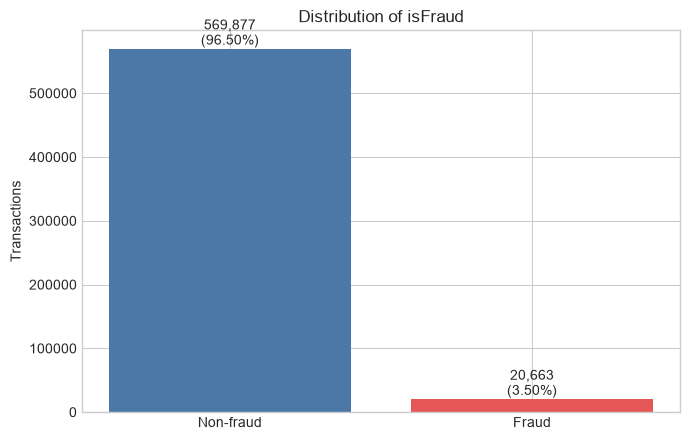

In [6]:
label_distribution = connection.sql(
    """
    SELECT
        CASE isFraud WHEN 0 THEN 'Non-fraud' WHEN 1 THEN 'Fraud' END AS label,
        COUNT(*) AS transaction_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 4) AS percentage
    FROM raw_transactions
    GROUP BY isFraud
    ORDER BY isFraud
    """
).df()
display(label_distribution)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    label_distribution['label'],
    label_distribution['transaction_count'],
    color=['#4C78A8', '#E45756'],
)
ax.set_title('Distribution of isFraud')
ax.set_ylabel('Transactions')
for bar, row in zip(bars, label_distribution.itertuples(), strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{row.transaction_count:,}\n({row.percentage:.2f}%)',
        ha='center',
        va='bottom',
    )
plt.tight_layout()
plt.show()

Fraud là lớp hiếm, nên accuracy có thể rất cao chỉ bằng cách dự đoán mọi giao dịch là non-fraud và không phản ánh khả năng phát hiện gian lận. Dự án báo cáo ROC-AUC để đo khả năng xếp hạng tổng quát và đặc biệt nhấn mạnh PR-AUC, vì precision-recall tập trung vào hiệu quả trên lớp fraud trong bối cảnh class imbalance.

## 6. Transaction Amount Analysis

Mẫu vẽ giữ toàn bộ fraud và lấy non-fraud theo `TransactionID % 20` để chart nhẹ nhưng tái lập được. Giá trị được biến đổi `log1p` vì distribution có right tail dài.

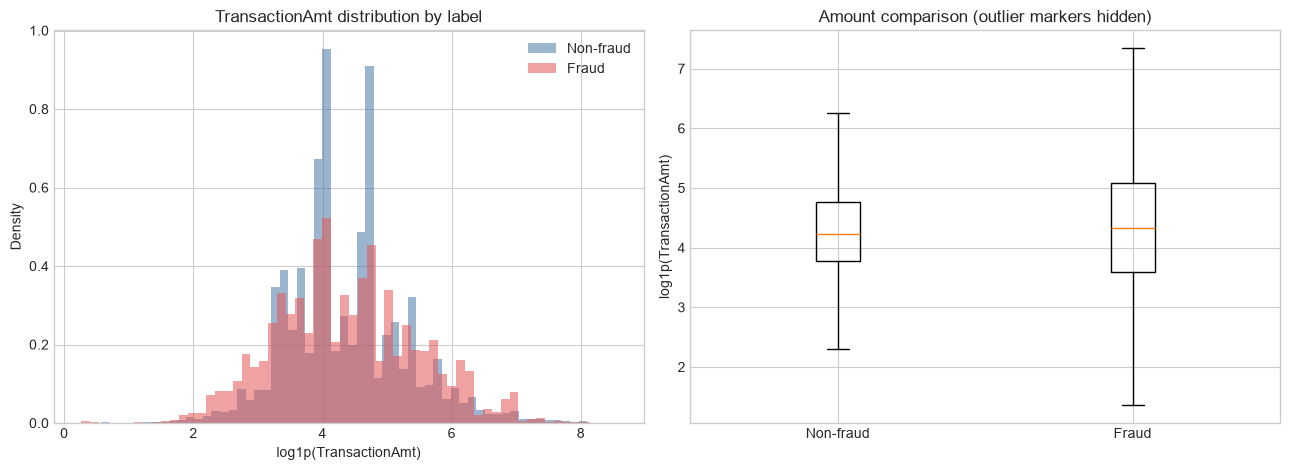

In [7]:
amount_sample = connection.sql(
    """
    SELECT TransactionAmt, isFraud
    FROM raw_transactions
    WHERE isFraud = 1
       OR (isFraud = 0 AND TransactionID % 20 = 0)
    """
).df()
amount_sample['log1p_amount'] = np.log1p(
    amount_sample['TransactionAmt'].clip(lower=0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for label, color, name in [(0, '#4C78A8', 'Non-fraud'), (1, '#E45756', 'Fraud')]:
    values = amount_sample.loc[amount_sample['isFraud'] == label, 'log1p_amount']
    axes[0].hist(values, bins=60, density=True, alpha=0.55, color=color, label=name)
axes[0].set_title('TransactionAmt distribution by label')
axes[0].set_xlabel('log1p(TransactionAmt)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].boxplot(
    [
        amount_sample.loc[amount_sample['isFraud'] == 0, 'log1p_amount'],
        amount_sample.loc[amount_sample['isFraud'] == 1, 'log1p_amount'],
    ],
    tick_labels=['Non-fraud', 'Fraud'],
    showfliers=False,
)
axes[1].set_title('Amount comparison (outlier markers hidden)')
axes[1].set_ylabel('log1p(TransactionAmt)')
plt.tight_layout()
plt.show()

Biến đổi log chỉ phục vụ visualization, không thay đổi raw amount hoặc feature calculation. Bảng data-quality phía trên giữ p95, p99 và max ở thang gốc để reviewer thấy mức độ skew/outlier.

## 7. Temporal Analysis

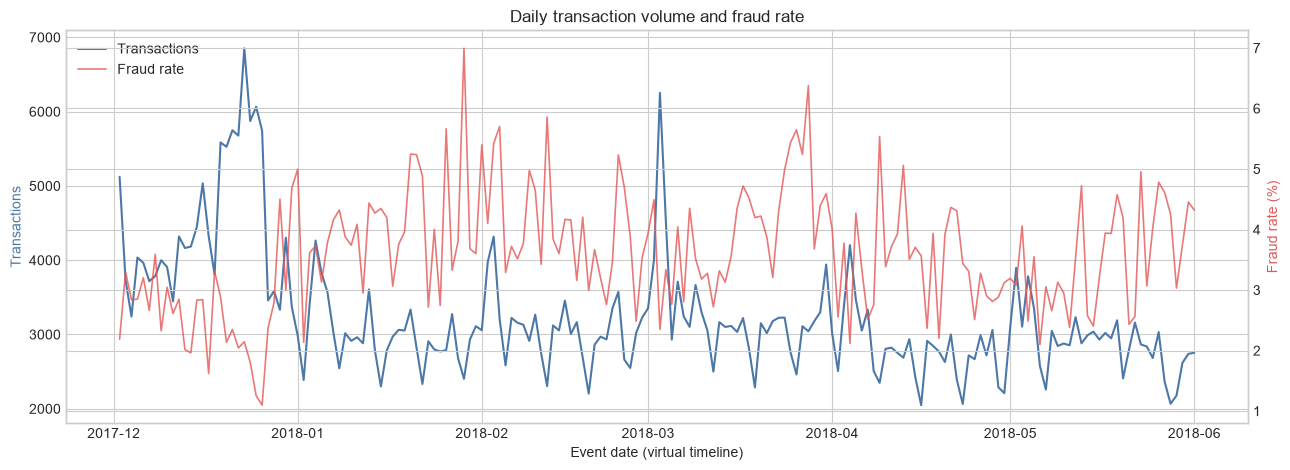

In [8]:
daily_activity = connection.sql(
    """
    SELECT
        DATE_TRUNC(
            'day',
            TIMESTAMP '2017-12-01 00:00:00'
                + CAST(TransactionDT AS BIGINT) * INTERVAL 1 SECOND
        ) AS event_date,
        COUNT(*) AS transaction_count,
        100.0 * AVG(isFraud) AS fraud_rate_pct
    FROM raw_transactions
    GROUP BY event_date
    ORDER BY event_date
    """
).df()
daily_activity['event_date'] = pd.to_datetime(daily_activity['event_date'])

fig, ax_count = plt.subplots(figsize=(13, 4.8))
ax_rate = ax_count.twinx()
ax_count.plot(
    daily_activity['event_date'], daily_activity['transaction_count'],
    color='#4C78A8', linewidth=1.5, label='Transactions',
)
ax_rate.plot(
    daily_activity['event_date'], daily_activity['fraud_rate_pct'],
    color='#E45756', linewidth=1.2, alpha=0.8, label='Fraud rate',
)
ax_count.set_title('Daily transaction volume and fraud rate')
ax_count.set_xlabel('Event date (virtual timeline)')
ax_count.set_ylabel('Transactions', color='#4C78A8')
ax_rate.set_ylabel('Fraud rate (%)', color='#E45756')
lines = ax_count.get_lines() + ax_rate.get_lines()
ax_count.legend(lines, [line.get_label() for line in lines], loc='upper left')
plt.tight_layout()
plt.show()

Transaction volume và fraud rate thay đổi theo event time. Vì dữ liệu có thứ tự thời gian và production chỉ biết quá khứ tại cutoff, project dùng event-time features và temporal split; random split có thể trộn các giai đoạn và tạo đánh giá lạc quan không phù hợp với serving thực tế.

## 8. Pseudo-Entity Candidate Analysis

SQL tính metrics nằm trong `entity_selection.py` để tái sử dụng và tránh duplicate. Notebook giữ toàn bộ phần so sánh, visualization và quyết định research.

In [9]:
entity_metrics = generate_entity_candidate_results(data_path)
display(entity_metrics)

,candidate,columns,total_rows,rows_with_uid,coverage_pct,n_entities,repeat_entity_pct,repeat_row_pct,median_txn_per_entity,p95_txn_per_entity,max_txn_per_entity
0,card1_card2_card5_addr1,card1 + card2 + card5 + addr1,590540,514655,87.15,38143,60.58,97.08,2.0,43,5866
1,card1_addr1,card1 + addr1,590540,524834,88.87,37531,60.52,97.18,2.0,45,5885
2,card1_card2_addr1,card1 + card2 + addr1,590540,516425,87.45,37280,60.49,97.15,2.0,45,5866
3,card1_card2_addr1_D1,card1 + card2 + addr1 + D1,590540,515348,87.27,231565,26.04,66.77,1.0,5,2425


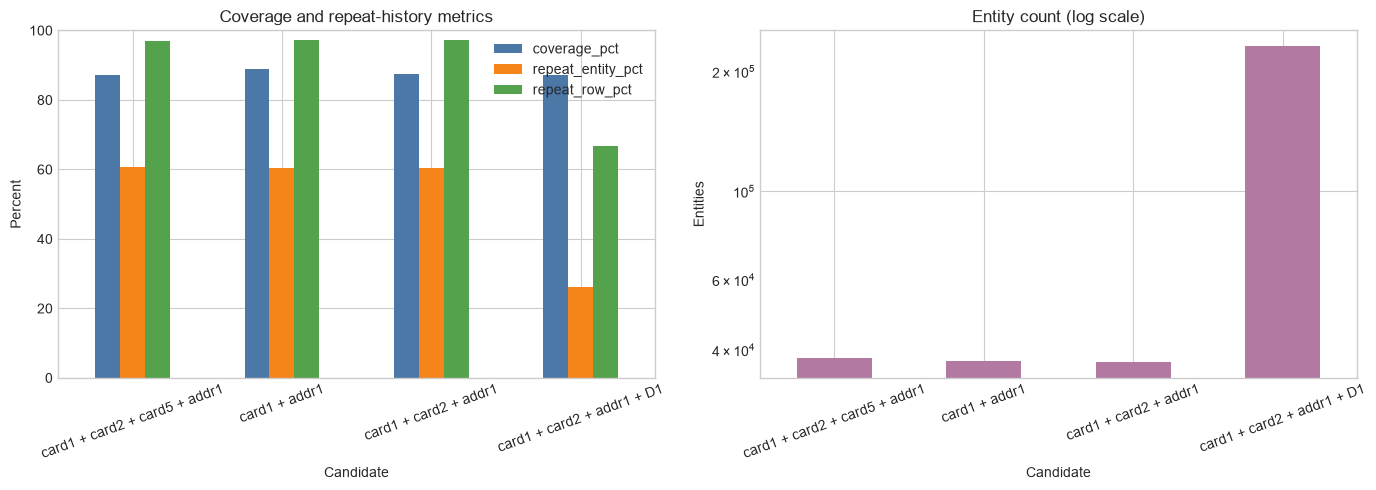

In [10]:
plot_data = entity_metrics.set_index('columns')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_data[['coverage_pct', 'repeat_entity_pct', 'repeat_row_pct']].plot(
    kind='bar', ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B']
)
axes[0].set_title('Coverage and repeat-history metrics')
axes[0].set_xlabel('Candidate')
axes[0].set_ylabel('Percent')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=20)

plot_data['n_entities'].plot(kind='bar', ax=axes[1], color='#B279A2')
axes[1].set_yscale('log')
axes[1].set_title('Entity count (log scale)')
axes[1].set_xlabel('Candidate')
axes[1].set_ylabel('Entities')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Research decision

Không dùng threshold tùy ý để tự động chọn. `card1 + addr1` có coverage cao nhất nhưng định danh thô hơn. Thêm `card2` tạo candidate cụ thể hơn trong khi coverage và repeat-history metrics gần như được giữ nguyên. Thêm `card5` tăng độ phức tạp nhưng không tạo cải thiện thực nghiệm đáng kể. Candidate chứa `D1` tạo 231.565 entity, median chỉ 1 giao dịch và repeat metrics giảm mạnh, cho thấy fragmentation. Vì cân bằng độ phủ, khả năng có lịch sử và độ chi tiết, project chọn **`card1 + card2 + addr1`**.

In [11]:
selected_candidate = 'card1_card2_addr1'
report = entity_metrics.copy()
report['selected'] = report['candidate'].eq(selected_candidate)
report['selection_reason'] = None
selected_row = report.loc[report['selected']].iloc[0]
report.loc[report['selected'], 'selection_reason'] = (
    f"Chọn từ phân tích thực nghiệm: coverage {selected_row['coverage_pct']:.2f}%, "
    f"repeat entity {selected_row['repeat_entity_pct']:.2f}%, repeat row "
    f"{selected_row['repeat_row_pct']:.2f}%, median "
    f"{selected_row['median_txn_per_entity']:.1f} giao dịch/entity; chi tiết hơn "
    "card1 + addr1 nhưng không bị fragmentation như candidate có D1."
)
exported_path = export_entity_candidate_results(report, output_report_path)
display(report)
print(f'Candidate được chọn: {selected_row["columns"]}')
print(f'Đã export: {exported_path}')

,candidate,columns,total_rows,rows_with_uid,coverage_pct,n_entities,repeat_entity_pct,repeat_row_pct,median_txn_per_entity,p95_txn_per_entity,max_txn_per_entity,selected,selection_reason
0,card1_card2_card5_addr1,card1 + card2 + card5 + addr1,590540,514655,87.15,38143,60.58,97.08,2.0,43,5866,False,None
1,card1_addr1,card1 + addr1,590540,524834,88.87,37531,60.52,97.18,2.0,45,5885,False,None
2,card1_card2_addr1,card1 + card2 + addr1,590540,516425,87.45,37280,60.49,97.15,2.0,45,5866,True,Chọn từ phân tích thực nghiệm: coverage 87.45%...
3,card1_card2_addr1_D1,card1 + card2 + addr1 + D1,590540,515348,87.27,231565,26.04,66.77,1.0,5,2425,False,None


Candidate được chọn: card1 + card2 + addr1
Đã export: c:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\entity_candidate_results.csv


In [12]:
connection.close()
print('EDA hoàn tất; DuckDB connection đã đóng.')

EDA hoàn tất; DuckDB connection đã đóng.
